# Lesson 2: Physical and mathematical fundaments of optimization algorithms
In this lesson multiple guided activities will be developed on the topic of random number generation

The following python libraries will be used:
- matplotlib
- numpy
- math
- scipy

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import norm

In the same fashion as the previous lesson, we stablish a color palette for the plots:

In [22]:
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#1b0033",
    "axes.facecolor": "#1b0033",
    "axes.edgecolor": "#ff71ce",
    "axes.labelcolor": "#ff71ce",
    "xtick.color": "#01cdfe",
    "ytick.color": "#01cdfe",
    "grid.color": "#05ffa1",
    "text.color": "#ff71ce",
    "font.family": "monospace"
})

# First guided activity
Implementing a congruential generator with:

a) Lineal: $a = 9$, $c = 1$, $M = 1103$

b) Lineal: $a = 1230$, $c = 1201$, $M = 1001$

c) Fibonacci: $a = 1$, $c = 1$, $\mu = 1$, $M = 10001$

The objective will be to generate the corresponding histogram with $10^6$ numbers and representing $n_k(n_k-1)$. 

To accomplish these tasks a function will be developed for it to be applied to lineal and Fibonacci generators depending on the provided parameters. The parameters for each of the cases will be:
- Lineal
    - a
    - b
    - M
    - N
- Fibonacci
    - a
    - b
    - M
    - N
    - c
    - $\mu$
    - $\nu$

And the following equations will be the ones implemented in the function:
$$
n_k = \left(a \cdot n_{k-1} + c\right) \;\text{mod}\; M
$$
$$
n_k = \left(a \cdot n_{k-\mu} + b \cdot n_{k-\nu} + c\right) \;\text{mod}\; M
$$

In [23]:
def congruential_generator(a:float, c:float, M:float, N:float, b = 0,  mu = 0, nu = 0, seed_1 = 0, seed_2=2):
    n_k = []
    aux_n_k = []

    n_k.append(seed_1)
    n_k.append(seed_2)
    for i in range(N):
        n_k.append((a * n_k[i-1+mu] + b * n_k[i-1+nu] + c)%M)

    return n_k


section_a = congruential_generator(a = 9, c = 1,M = 1103,N = 10000)
section_b = congruential_generator(a = 1230, c = 1201, M = 10001, N = 10000)
section_c = congruential_generator(a = 1, c = 1, M = 10001,N = 10000, mu = 1)

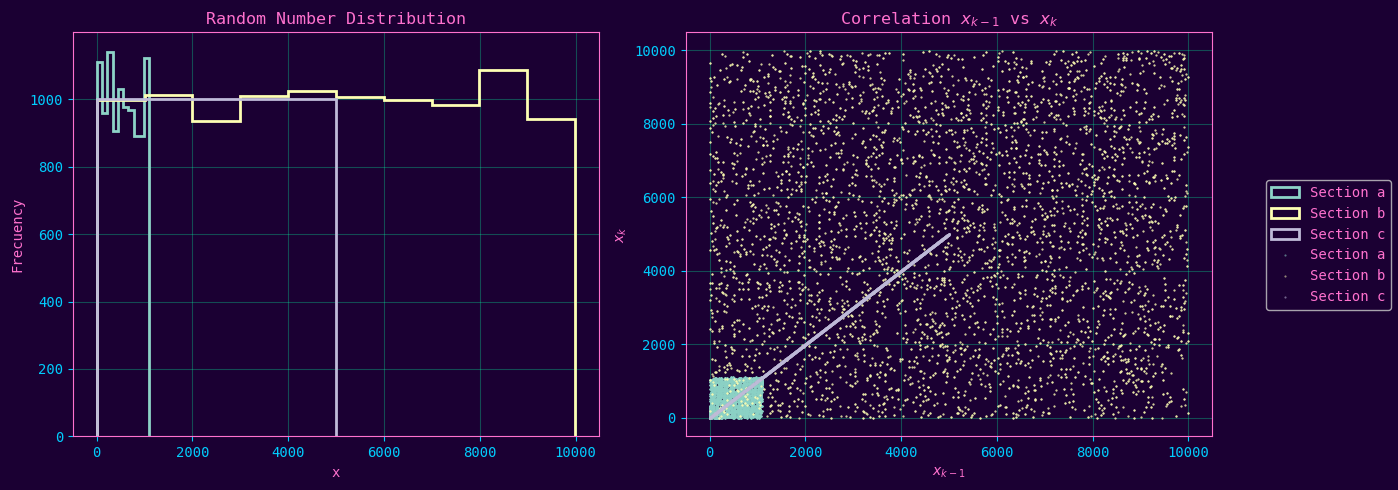

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.grid(alpha=0.3)

axes[0].hist(
    section_a,
    histtype='step',
    lw=2,
    label='Section a'
)

axes[0].hist(
    section_b,
    histtype='step',
    lw=2,
    label='Section b'
)

axes[0].hist(
    section_c,
    histtype='step',
    lw=2,
    label='Section c'
)

axes[0].set_title('Random Number Distribution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Frecuency')

axes[1].plot(
    section_a[:-1], section_a[1:],
    'o',
    ms=0.5,
    alpha=0.6,
    label='Section a'
)

axes[1].plot(
    section_b[:-1], section_b[1:],
    'o',
    ms=0.5,
    alpha=0.6,
    label='Section b'
)

axes[1].plot(
    section_c[:-1], section_c[1:],
    'o',
    ms=0.5,
    alpha=0.6,
    label='Section c'
)

axes[1].set_title(r'Correlation $x_{k-1}$ vs $x_k$')
axes[1].set_xlabel(r'$x_{k-1}$')
axes[1].set_ylabel(r'$x_k$')

fig.legend(
    loc='center right',
    fontsize=10,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


The following observations can be made on the obtained data:
- About the histogram:
    - Looking at the generated histogram one would be able to notice that, for section A multiple significant variations exist between each of the evaluated ranges, this meaning that a significant inconsistency exists when comparing the results obtained on the other two sections.
    - Nonetheless, the biggest variation between randomly generated numbers in each of the selected ranges can be attributed to the values between 0.8-0.9 and 0.9 1.0 that appear on section B. Even with this significant variation, the generated numbers for each evaluated range oscilate between de 1000s in this section when compared to the previous one.
    - Lastly, it is noticeable that the case in which the randomly generated numbers in section C are the most evenly distributed, oscilating between the 10000s for each of the 10 evaluated ranges.
- About the scatter plot: 
    - There is an evolution between the methods used in each of the different sections when referring to the difference between a random number and the one generated based on it. In section A, a lineal correlation exists in this case, which is characteristic of the lineal congruential generators due to the equation used for the number generation.
    - In section's B case it can be noticed an improvement on the dispersion of the points, these being distributed on a more equally spaced fashion, but still facing the same problem as section A.
    - Finally, on section C, due to it being a Fibonacci generator, the improvement is significant when compared to the previous sections, resulting on a more equitative distribution of randomly generated numbers.

# Second guided activity
In this exercise the inverse transform method will be developed

## Section A

The goal is to generate numbers following an exponential distribution starting from random numbers $u \sim U[0,1]$:

$$
p_x(x) = \lambda e^{-\lambda x}, \quad x \in [0,1]
$$

Using, for example, $\lambda = 3$, the resulting histogram should be plotted.

To carry out this exercise, we first take the probability density function given above and use the equation

$$
F_x(x) \equiv \int_{x_{\min}}^{x} p_x(x')\,dx'
$$

in order to obtain the Cumulative Distribution Function (CDF). We then equate the values and solve for the variable that will be sampled.

In our case, the calculations yield:

$$
F(x) = 1 - e^{-\lambda x}
$$

$$
u = 1 - e^{-\lambda x}
\quad \Rightarrow \quad
x = -\frac{1}{\lambda}\ln(1-u)
$$

This last expression can be simplified to:

$$
x = -\frac{\ln(u)}{\lambda}
$$

Random numbers uniformly distributed between 0 and 1 will then be generated using the $\texttt{random}$ library and substituted into this equation to obtain random numbers following an $\textbf{exponential distribution}$. Note that the resulting distribution is exponential, not Gaussian.

In [25]:
def random_number_array_generator(number_ammount: int) -> list[list[float], list[float]]:
    return np.random.rand(number_ammount), np.random.rand(number_ammount)

In [26]:
def random_exponential_number_generator(random_number_array,lamda):
    return -np.log(random_number_array)/ lamda

lamda = 3
random_number_array_x, random_number_array_y= random_number_array_generator(1000000)
random_exponential_number_array = random_exponential_number_generator(random_number_array_x, lamda)

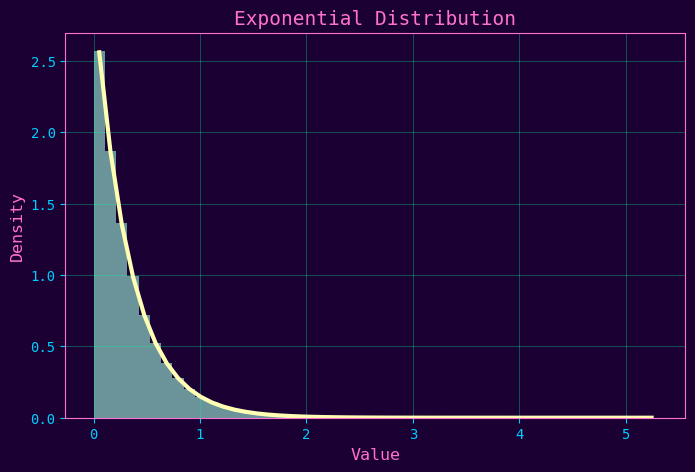

In [27]:
plt.figure(figsize=(8, 5))

counts, bins, patches = plt.hist(
random_exponential_number_array,
    bins=50,
    density=True,
    alpha=0.7,
    label="Simulation",
)

midpoints = (bins[:-1]+bins[1:])/2
plt.plot(
    midpoints,
    lamda*np.exp(-lamda*midpoints),
    linewidth=3,
    label="Theoretical",
)

plt.title("Exponential Distribution", fontsize=14)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()


When comparing the obtained histogram with overlaped exponential function it can be concluded that the obtained result fits remarkably well, indicating lower density the higher the obtained number is.

## Second Section

This same procedure is also required for the generation of Gaussian numbers. In this case, the equations used to obtain the Gaussian numbers have been derived in the same manner as the previous case, albeit slightly more complex due to generating numbers in two dimensions:

$$
x = \sqrt{-2 \log{(u_1)}} \cos (2\pi \times u_2)
$$
$$
y = \sqrt{-2 \log{(u_1)}} \sin (2\pi \times u_2)
$$
> *NOTE:* A Gaussian random number is one that follows a bell-shaped distribution (Gaussian distribution), as opposed to the uniform distribution seen in the previous exercise.

In [28]:
def random_gauss_coordinate_generator(x,y):
    return np.sqrt(-2 * np.log(x)) * np.cos(2 * np.pi*y), np.sqrt(-2 * np.log(x)) * np.sin(2 * np.pi*y)

random_gauss_generated_coordinate_x, random_gauss_generated_coordinate_y = random_gauss_coordinate_generator(random_number_array_x,random_number_array_y)

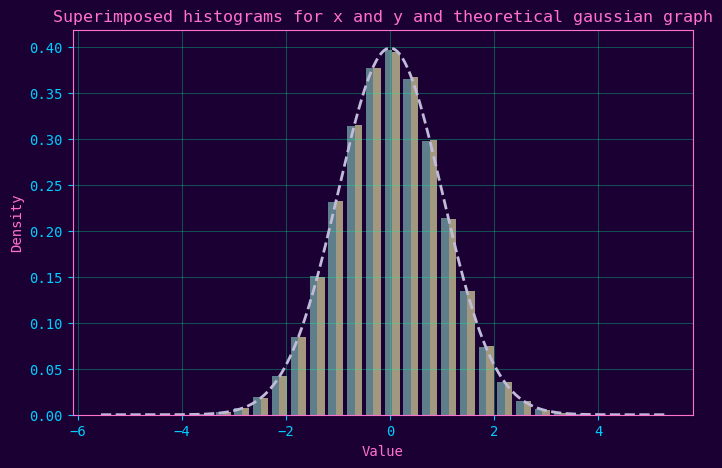

In [29]:
bins = np.linspace(random_gauss_generated_coordinate_x.min(), random_gauss_generated_coordinate_y.max(), 31)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [random_gauss_generated_coordinate_x, random_gauss_generated_coordinate_y],
    bins=bins,
    density=True,
    alpha=0.6,
    label=["X","Y"]
)

x_vals = np.linspace(bins[0], bins[-1], 400)
gauss = norm.pdf(x_vals, 0, 1)

ax.plot(
    x_vals,
    gauss,
    "--",
    linewidth=2,
    label="Theoretical Gaussian N(0,1)"
)

ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title(
    "Superimposed histograms for x and y and theoretical gaussian graph"
)

ax.grid(alpha=0.3)

plt.show()

As in the case of the exponential distribution, the fitness of the results deviates slightly from the reference Gaussian function, yet it provides a very good outcome.

It is worth noting that in the exponential case, the results begin to reflect the influence of said function on the generated numbers starting at around 10,000 generated numbers, whereas in the Gaussian case, this threshold is slightly higher.

# Third Guided Activity

In this third activity, we are required to calculate exponential and Gaussian numbers in the same manner as the previous section, but this time utilizing the acceptance-rejection method.

This method consists of 3 steps that are iterated until the desired result is obtained. The first step involves uniformly generating points within an area bounded by $[x_{min}, x_{max}] \times [0, y_{max}]$. Once all the points are obtained, the next step is to verify whether the generated points lie above or below the function being compared against. If they are greater, they are rejected; if they are equal or less, they are accepted. These steps are repeated until the desired outcome is achieved.

We will begin by defining two functions—one for each of the distributions we are going to evaluate (the exponential and the Gaussian)—where the variables of these functions are passed as parameters and the resulting value is returned:

In [30]:
def exponential_function(lamda ,random_number):
    return lamda*np.exp(-lamda*random_number)

def gaussian_function(random_number):
    return (1/np.sqrt(2*np.pi))*np.exp(-(random_number**2)/2)

We will generate random numbers and then check if they correspond to the defined functions, but first the initial conditions will be defined:

In [31]:
LAMDA = 2.
MIN_EXPONENTIAL = (0., 0.)
MAX_EXPONENTIAL = (5./LAMDA, LAMDA)
MIN_GAUSSIAN = (-4., 0.)
MAX_GAUSSIAN = (4., 1./np.sqrt(2*np.pi))
RANDOM_NUMBER_COUNT = 10**6

In [32]:
number_of_tries_exponential = 0

random_number_array_exponential = np.zeros(RANDOM_NUMBER_COUNT)
for i in range(RANDOM_NUMBER_COUNT):
    accepted = False
    while accepted == False:
        random_number_try = np.random.uniform(MIN_EXPONENTIAL[0],MAX_EXPONENTIAL[0])
        random_number_auxiliar = np.random.uniform(MIN_EXPONENTIAL[1],MAX_EXPONENTIAL[1])
        if random_number_auxiliar < exponential_function(LAMDA,random_number_try): accepted = True
        number_of_tries_exponential = number_of_tries_exponential + 1
    random_number_array_exponential[i] = random_number_try

print(number_of_tries_exponential)

5030496


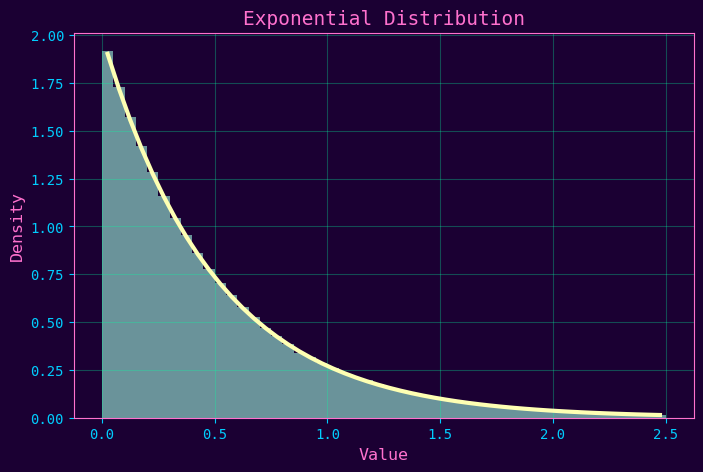

In [33]:
plt.figure(figsize=(8, 5))

counts, bins, patches = plt.hist(
    random_number_array_exponential,
    bins=50,
    density=True,
    alpha=0.7,
    label="Simulation",
)

midpoints = (bins[:-1]+bins[1:])/2 # genera un array con los puntos medios de cada bin
plt.plot(
    midpoints,
    LAMDA*np.exp(-LAMDA*midpoints),
    linewidth=3,
    label="Theoretical",
)

plt.title("Exponential Distribution", fontsize=14)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()


In [ ]:
number_of_tries_gaussian = 0

random_number_array_gaussian = np.zeros(RANDOM_NUMBER_COUNT)
for i in range(RANDOM_NUMBER_COUNT):
    accepted = False
    while accepted == False:
        random_number_try = np.random.uniform(MIN_EXPONENTIAL[0],MAX_EXPONENTIAL[0])
        random_number_auxiliar = np.random.uniform(MIN_EXPONENTIAL[1],MAX_EXPONENTIAL[1])
        if random_number_auxiliar < gaussian_function(random_number_try): accepted = True
        number_of_tries_gaussian = number_of_tries_gaussian + 1
    random_number_array_gaussian[i] = random_number_try

print(number_of_tries_gaussian)

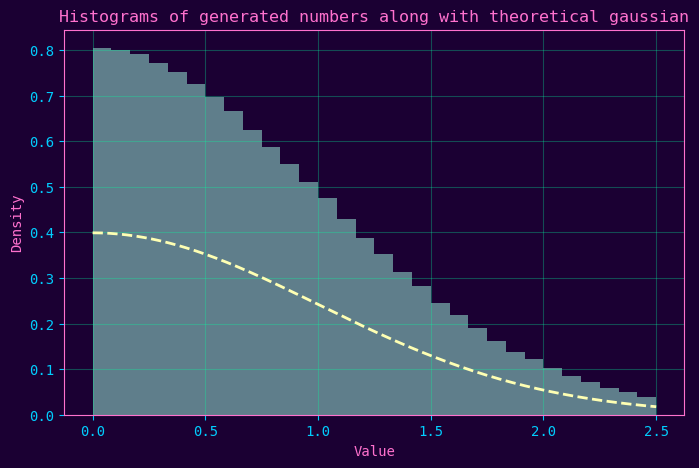

In [ ]:
bins = np.linspace(random_number_array_gaussian.min(), random_number_array_gaussian.max(), 31)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    random_number_array_gaussian,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Generated data"
)

x_vals = np.linspace(bins[0], bins[-1], 400)
gauss = norm.pdf(x_vals, 0, 1)

ax.plot(
    x_vals,
    gauss,
    "--",
    linewidth=2,
    label="Theoretical gaussian"
)

ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title(
    "Histograms of generated numbers along with theoretical gaussian",
)

ax.grid(alpha=0.3)

plt.show()

When applying this method once again to the exponential and Gaussian functions, it can be observed that the obtained results are adequate and align with the reference functions when the number of generated values exceeds 10,000; however, better results are achieved with a larger quantity of numbers.

Comparing this acceptance-rejection method with the inverse transform method reveals the following:
- At first glance, a higher number of values must be evaluated to generate an adequate result compared to the inverse transform method. While the latter yields good results starting from 10,000 numbers, this threshold must be higher for the acceptance-rejection method.
- In the case of the acceptance-rejection method, it is necessary to generate a greater number of random numbers than the final amount obtained as a result, since a portion of them is discarded for not meeting the established requirements. Conversely, with the inverse transform method, all generated numbers are accepted.
- It is worth mentioning that the acceptance-rejection method does not require additional analytical derivations, unlike the inverse transform method.
- Regarding execution time to obtain 100,000 numbers, the inverse transform method requires 0.0 seconds for both distributions, whereas the acceptance-rejection method takes 13.7 seconds